# Proyecto Semestral

IN5244: Ciencia de los Datos - Otoño 2026

---

### Cuerpo Docente:

- Profesor: Pamela Jervis, Richard Weber.
- Auxiliares: Guillermo Escobar, Isadora Madrid.
- Ayudantes: Maximiliano Farren, Ignacio Alarcon, Francisco Mora, Flavia Gutiérrez, Camila Laura


### Estudiantes
- Sofía Alarcón
- Felipe Muñoz 
- Trinidad Peña
- Benjamín Soto

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go



import umap  # pip install umap-learn


/Users/felijandro/Documents/Universidad/12voSemestre/CienciasdelosDatos/IN5244_CienciadeDatos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV


from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LogisticRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb


from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score


from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, mean_squared_error, r2_score)

In [19]:
import missingno as msno

In [4]:
import shap

In [5]:
import warnings
warnings.filterwarnings('ignore')
import random
SEED = 42
np.random.seed(SEED)

# 0. Setup & carga de datos

In [6]:
url = "https://raw.githubusercontent.com/FeLiJaNdRo/IN5244_CienciadeDatos/main/Proyecto/Base_de_datos.xlsx"
df = pd.read_excel(url)

# 1. EDA



In [22]:
# Primeras 5 filas
df.head()

,sitecode,sitename,sitetype,sitetypenum,year,survyear,weight,stratum,PSU,record,...,q78,q79,q80,q81,q82,q83,q84,q85,q86,q87
0,AB,"Albuquerque, NM (AB)",District,1,2019,15,8.6390,6,2,30264,...,NaN,2.0,NaN,2.0,2.0,1.0,NaN,6.0,1.0,2.0
1,AB,"Albuquerque, NM (AB)",District,1,2019,15,9.0259,9,2,30265,...,NaN,5.0,NaN,2.0,2.0,1.0,NaN,4.0,1.0,3.0
2,AB,"Albuquerque, NM (AB)",District,1,2019,15,1.4796,14,4,30266,...,NaN,1.0,NaN,2.0,2.0,1.0,NaN,3.0,1.0,1.0
3,AB,"Albuquerque, NM (AB)",District,1,2019,15,11.6977,7,7,30267,...,NaN,1.0,NaN,2.0,2.0,1.0,NaN,5.0,1.0,1.0
4,AB,"Albuquerque, NM (AB)",District,1,2019,15,5.1645,13,5,30268,...,NaN,1.0,NaN,3.0,3.0,5.0,NaN,1.0,1.0,2.0


Se separan las columnas por tipo según la documentación

In [21]:
# Variables de muestra (Son identificadores, no se usan como features)
sample_cols = ['sitecode', 'sitename', 'sitetype', 'sitetypenum',
               'year', 'survyear', 'weight', 'stratum', 'PSU', 'record']

# Variables demográficas
demographic_cols = ['age', 'sex', 'grade', 'race4', 'race7']

# Variables BMI (continuas)
bmi_cols = ['stheight', 'stweight', 'bmi', 'bmipct', 'qnobese', 'qnowt']

# Variables de identidad sexual/género
sexual_identity_cols = ['q65', 'q64', 'q63', 'sexid', 'sexid2',
                        'sexpart', 'sexpart2', 'transg', 'sextrans']

# Variables del cuestionario (q8–q87, excluyendo q63–q65 ya clasificadas)
questionnaire_cols = [c for c in df.columns
                      if c.startswith('q') and c not in
                      sample_cols + demographic_cols + bmi_cols + sexual_identity_cols]

print(f"Total columnas:          {df.shape[1]}")
print(f"Variables de muestra:    {len(sample_cols)}")
print(f"Variables demográficas:  {len(demographic_cols)}")
print(f"Variables BMI:           {len(bmi_cols)}")
print(f"Variables id. sexual:    {len(sexual_identity_cols)}")
print(f"Variables cuestionario:  {len(questionnaire_cols)}")

Total columnas:          107
Variables de muestra:    10
Variables demográficas:  5
Variables BMI:           6
Variables id. sexual:    9
Variables cuestionario:  77


### Visión general del Dataset

In [26]:
print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")

print("Años disponibles:", sorted(df['year'].unique()))
print("Tipos de sitio:  ", df['sitetype'].value_counts().to_dict())
df.head(5)

Shape: 99,778 filas × 107 columnas

Años disponibles: [np.int64(2019), np.int64(2021), np.int64(2023)]
Tipos de sitio:   {'District': 99778}


,sitecode,sitename,sitetype,sitetypenum,year,survyear,weight,stratum,PSU,record,...,q78,q79,q80,q81,q82,q83,q84,q85,q86,q87
0,AB,"Albuquerque, NM (AB)",District,1,2019,15,8.6390,6,2,30264,...,NaN,2.0,NaN,2.0,2.0,1.0,NaN,6.0,1.0,2.0
1,AB,"Albuquerque, NM (AB)",District,1,2019,15,9.0259,9,2,30265,...,NaN,5.0,NaN,2.0,2.0,1.0,NaN,4.0,1.0,3.0
2,AB,"Albuquerque, NM (AB)",District,1,2019,15,1.4796,14,4,30266,...,NaN,1.0,NaN,2.0,2.0,1.0,NaN,3.0,1.0,1.0
3,AB,"Albuquerque, NM (AB)",District,1,2019,15,11.6977,7,7,30267,...,NaN,1.0,NaN,2.0,2.0,1.0,NaN,5.0,1.0,1.0
4,AB,"Albuquerque, NM (AB)",District,1,2019,15,5.1645,13,5,30268,...,NaN,1.0,NaN,3.0,3.0,5.0,NaN,1.0,1.0,2.0


### Valores faltantes

In [27]:
missing = pd.DataFrame({
    'n_missing': df.isnull().sum(),
    'pct_missing': df.isnull().mean() * 100
}).sort_values('pct_missing', ascending=False)

# Solo columnas con nulos
missing_nonzero = missing[missing['n_missing'] > 0]
print(f"Columnas con nulos: {len(missing_nonzero)} / {df.shape[1]}\n")

# Resumen por grupos
for group_name, cols in [
    ("Demográficas",   demographic_cols),
    ("BMI",            bmi_cols),
    ("Id. Sexual",     sexual_identity_cols),
    ("Cuestionario",   questionnaire_cols),
]:
    group_missing = missing.loc[[c for c in cols if c in missing.index], 'pct_missing']
    print(f"{group_name:15s} → promedio nulos: {group_missing.mean():.1f}%  |  "
          f"máx: {group_missing.max():.1f}%  |  "
          f"columnas >50% nulos: {(group_missing > 50).sum()}")

Columnas con nulos: 97 / 107

Demográficas    → promedio nulos: 2.1%  |  máx: 3.7%  |  columnas >50% nulos: 0
BMI             → promedio nulos: 13.9%  |  máx: 13.9%  |  columnas >50% nulos: 0
Id. Sexual      → promedio nulos: 40.1%  |  máx: 71.2%  |  columnas >50% nulos: 4
Cuestionario    → promedio nulos: 30.5%  |  máx: 80.7%  |  columnas >50% nulos: 17


### Distribuciones Demográficas

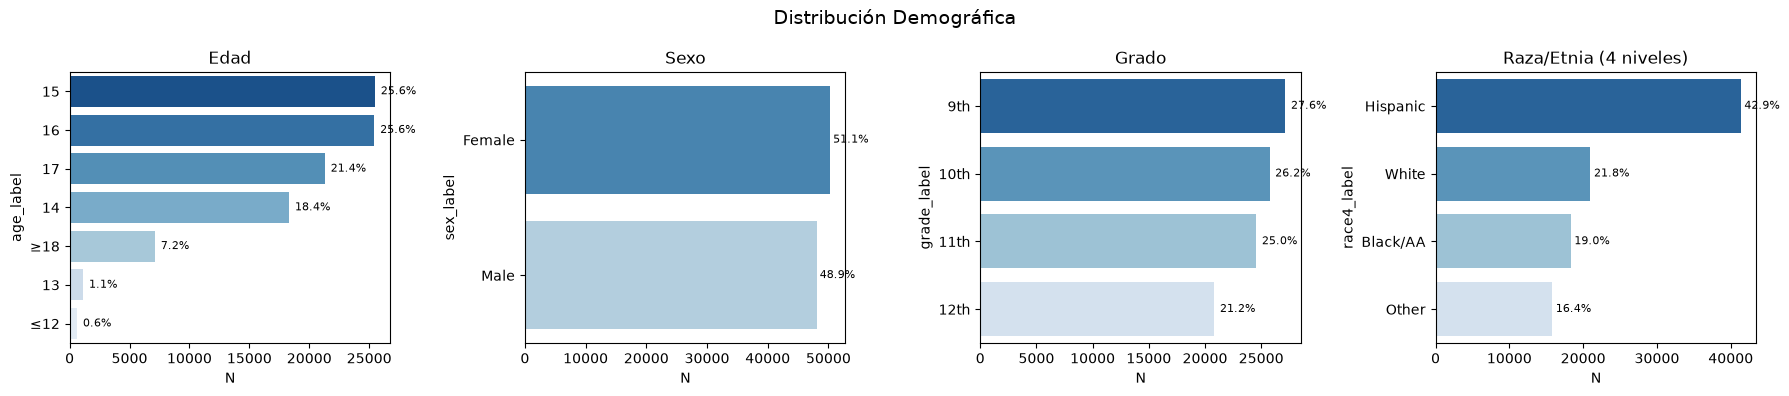

In [31]:
# Mapeos según la documentación
age_map    = {1:'≤12', 2:'13', 3:'14', 4:'15', 5:'16', 6:'17', 7:'≥18'}
sex_map    = {1:'Female', 2:'Male'}
grade_map  = {1:'9th', 2:'10th', 3:'11th', 4:'12th', 5:'Other'}
race4_map  = {1:'White', 2:'Black/AA', 3:'Hispanic', 4:'Other'}

df['age_label']   = df['age'].map(age_map)
df['sex_label']   = df['sex'].map(sex_map)
df['grade_label'] = df['grade'].map(grade_map)
df['race4_label'] = df['race4'].map(race4_map)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, label in zip(axes,
                           ['age_label', 'sex_label', 'grade_label', 'race4_label'],
                           ['Edad', 'Sexo', 'Grado', 'Raza/Etnia (4 niveles)']):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette='Blues_r')
    ax.set_title(label)
    ax.set_xlabel("N")
    # Añadir porcentajes
    total = counts.sum()
    for i, v in enumerate(counts.values):
        ax.text(v + total * 0.005, i, f'{v/total*100:.1f}%', va='center', fontsize=8)

plt.suptitle("Distribución Demográfica", fontsize=14)
plt.tight_layout()
plt.show()

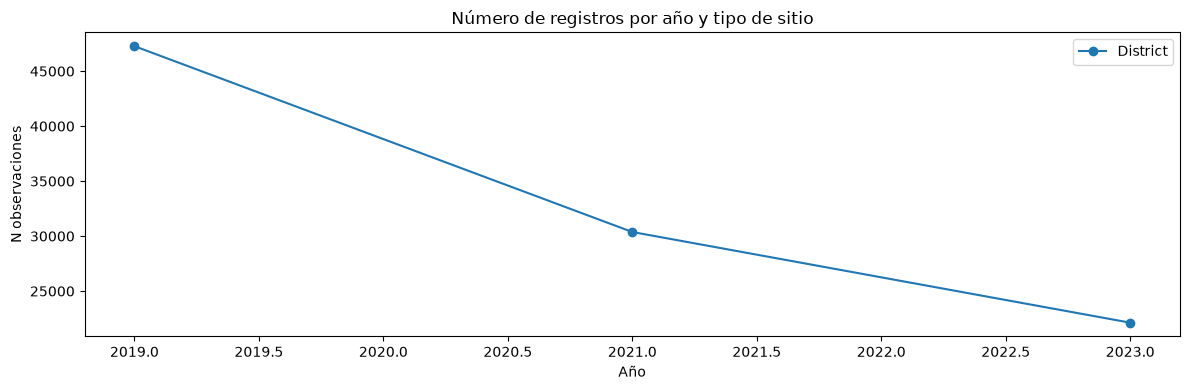

In [32]:
# Evolución temporal de la muestra
yearly = df.groupby(['year', 'sitetype']).size().reset_index(name='n')
fig, ax = plt.subplots(figsize=(12, 4))
for stype in yearly['sitetype'].unique():
    sub = yearly[yearly['sitetype'] == stype]
    ax.plot(sub['year'], sub['n'], marker='o', label=stype)
ax.set_title("Número de registros por año y tipo de sitio")
ax.set_xlabel("Año")
ax.set_ylabel("N observaciones")
ax.legend()
plt.tight_layout()
plt.show()

### Distribuciones BMI (Variables Continuas)

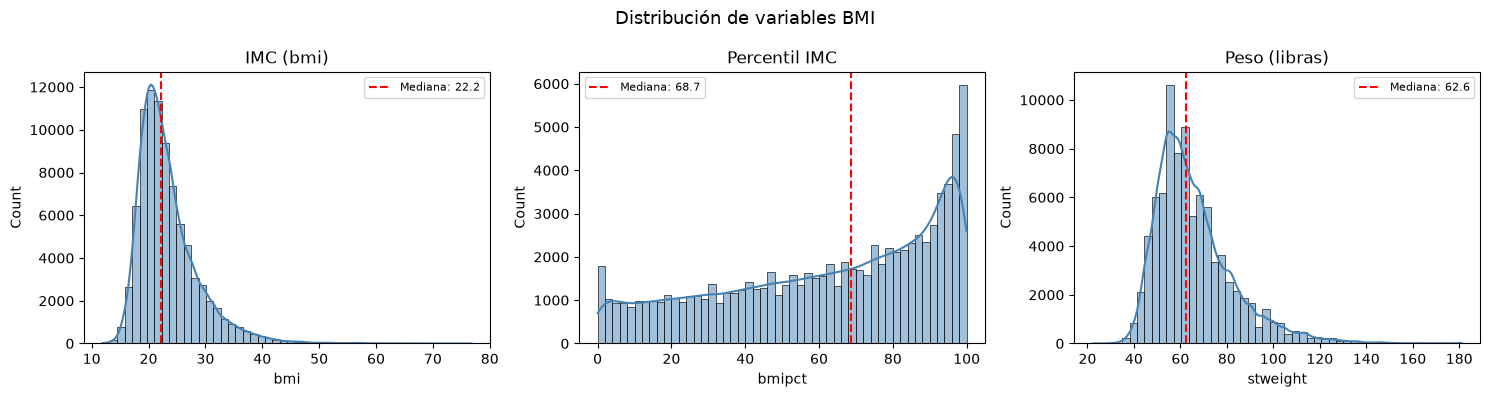

Obesidad  (qnobese=1): 12.7%
Sobrepeso (qnowt=1):   13.9%


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                            ['bmi', 'bmipct', 'stweight'],
                            ['IMC (bmi)', 'Percentil IMC', 'Peso (libras)']):
    data = df[col].dropna()
    sns.histplot(data, ax=ax, kde=True, color='steelblue', bins=50)
    ax.axvline(data.median(), color='red', linestyle='--', label=f'Mediana: {data.median():.1f}')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Distribución de variables BMI", fontsize=13)
plt.tight_layout()
plt.show()

# Prevalencia de obesidad y sobrepeso
print("Obesidad  (qnobese=1):", f"{(df['qnobese']==1).mean()*100:.1f}%")
print("Sobrepeso (qnowt=1):  ", f"{(df['qnowt']==1).mean()*100:.1f}%")

**IMC (bmi)**
Distribución asimétrica positiva (sesgo a la derecha).

La mediana es 22.2, que cae en rango normal según la OMS (18.5–24.9), lo que es esperado para adolescentes.
La masa se concentra entre 15 y 30, con una cola larga hacia valores altos (hasta ~80), que corresponde a casos de obesidad severa.
El peak está alrededor de 20–22, lo cúal es típico en adolescentes de secundaria.
Los valores extremos (>40) son outliers que habrá que tratar en el preprocesamiento, probablemente errores de auto-reporte de talla/peso.


**Percentil IMC (bmipct)**
Distribución bimodal con forma inusual.

Hay un peak inicial cerca del percentil 0–5 y luego la distribución sube fuertemente hacia percentiles altos (85–99).
Esto no es un error: el percentil IMC en adolescentes se calcula ajustado por edad y sexo, y la acumulación en percentiles altos refleja la alta prevalencia de sobrepeso/obesidad en la muestra estadounidense.
La mediana de 68.7 indica que la mitad de los estudiantes está en el percentil 69 o superior, lo que es preocupante desde el punto de vista de salud pública.
El valle entre percentil 10 y 60 seguido del peak al final es una característica conocida de las distribuciones de IMC percentilado en poblaciones con alta prevalencia de obesidad.


**Peso (stweight, en libras)**
Distribución asimétrica positiva, similar al IMC.

La mediana es 62.6 kg equivalente (138 libras aprox.), coherente con el peso esperado en adolescentes de 14–17 años.
Cola larga a la derecha con valores hasta ~180 libras, que corresponden a casos extremos.
El peak está alrededor de 55–65 libras, aunque esto parece bajo si son libras. Vale la pena verificar las unidades en el dataset porque la documentación indica que el peso se reporta en libras, por lo que la mediana de 62.6 podría estar en kg si hubo conversión.

### Prevalencia Conductas de Riesgo
Estas son Variables clave para la métrica de bienestar. Para ello, se calcula en base a la prevalencia. Esta transformación, es simplemente el porcentaje de personas que tienen una característica en un momento dado.La prevalencia es simplemente el porcentaje de personas que tienen una característica en un momento dado.

Se realiza un análisis univariado de las conductas de riesgo

In [59]:
# Corrección q29: binarizar correctamente
# 1 = "0 veces" → No intentó suicidio
# 2,3,4,5      → Sí intentó suicidio
# NaN          → se mantiene NaN

df['q29_bin'] = df['q29'].apply(
    lambda x: 0 if x == 1 else (1 if x > 1 else np.nan)
)

# Verificación
print("Distribución q29_bin:")
print(df['q29_bin'].value_counts(dropna=False))
print(f"\n% Intentó suicidio: {df['q29_bin'].mean()*100:.1f}%")
print(f"% No intentó:       {(df['q29_bin']==0).mean()*100:.1f}%")
print(f"% Nulos:            {df['q29_bin'].isna().mean()*100:.1f}%")

Distribución q29_bin:
q29_bin
0.0    72612
NaN    18856
1.0     8310
Name: count, dtype: int64

% Intentó suicidio: 10.3%
% No intentó:       72.8%
% Nulos:            18.9%


In [63]:
# Diccionario completo: variable → (descripción, tipo de escala) y Agrupadas por dominio según la documentación YRBS
conductas = {

    # ── SALUD MENTAL ──────────────────────────────────
    'q26': ('Tristeza/desesperanza (≥2 sem)',      'binary'),
    'q27': ('Consideró suicidio',                  'binary'),
    'q28': ('Planeó suicidio',                     'binary'),
    'q29_bin': ('Intentó suicidio',                    'binary'),
    'q84': ('Salud mental no buena',               'ordinal',
            {1:'Nunca', 2:'Raramente', 3:'A veces',
             4:'Casi siempre', 5:'Siempre'}),

    # ── SUEÑO Y ACTIVIDAD FÍSICA ──────────────────────
    'q85': ('Horas de sueño (noche escolar)',       'ordinal',
            {1:'≤4h', 2:'5h', 3:'6h', 4:'7h',
             5:'8h', 6:'9h', 7:'≥10h'}),
    'q76': ('Días activo ≥60 min',                 'ordinal',
            {1:'0d', 2:'1d', 3:'2d', 4:'3d',
             5:'4d', 6:'5d', 7:'6d', 8:'7d'}),

    # ── VIOLENCIA Y ACOSO ─────────────────────────────
    'q24': ('Bullying en escuela',                 'binary'),
    'q25': ('Cyberbullying',                       'binary'),
    'q15': ('Amenazado con arma en escuela',       'binary_first'),
    'q16': ('Pelea física',                        'binary_first'),
    'q19': ('Forzado a tener relaciones',          'binary'),
    'q20': ('Violencia sexual (últ. 12m)',         'binary_first'),

    # ── SUSTANCIAS ────────────────────────────────────
    'q33': ('Cigarrillos (últimos 30d)',            'binary_first'),
    'q36': ('Vaporizador/e-cig (últimos 30d)',      'binary_first'),
    'q42': ('Alcohol (últimos 30d)',                'binary_first'),
    'q43': ('Binge drinking (últimos 30d)',         'binary_first'),
    'q48': ('Marihuana (últimos 30d)',              'binary_first'),
    'q49': ('Medicamentos sin receta (vida)',       'binary_first'),

    # ── NUTRICIÓN ─────────────────────────────────────
    'q75': ('Días que desayunó (últ. 7d)',         'ordinal',
            {1:'0d', 2:'1d', 3:'2d', 4:'3d',
             5:'4d', 6:'5d', 7:'6d', 8:'7d'}),
    'q74': ('Consumo de soda/pop (últ. 7d)',       'ordinal',
            {1:'Nunca', 2:'1-3x', 3:'4-6x',
             4:'1x/día', 5:'2x/día', 6:'3x/día', 7:'≥4x/día'}),

    # ── TECNOLOGÍA Y ENTORNO ──────────────────────────
    'q80': ('Frecuencia redes sociales',           'ordinal',
            {1:'No uso', 2:'Pocas/mes', 3:'1x/sem',
             4:'Pocas/sem', 5:'1x/día',
             6:'Varias/día', 7:'1x/hora', 8:'>1x/hora'}),
    'q86': ('Vivienda inestable (últimos 30d)',    'binary_first'),
    'q87': ('Notas A/B en escuela',                'binary'),
}

In [64]:
def get_prevalence(df, col, var_type, mapping=None):
    """
    Devuelve DataFrame con categoría y prevalencia (%).
    - binary:       1=Sí riesgo, 2=No
    - binary_first: 1=sin riesgo (0 veces), resto=riesgo → muestra distribución completa
    - ordinal:      usa mapping provisto
    """
    series = df[col].dropna()

    if var_type == 'binary':
        counts = series.value_counts().rename({1: 'Sí (riesgo)', 2: 'No'})
        order  = ['No', 'Sí (riesgo)']

    elif var_type == 'binary_first':
        # Mostrar cada categoría original pero etiquetar la primera como "sin riesgo"
        counts = series.value_counts().sort_index()
        counts.index = [f'Cat. {int(i)}' for i in counts.index]
        order = list(counts.index)

    elif var_type == 'ordinal':
        counts = series.map(mapping).value_counts()
        order  = list(mapping.values())

    pct = (counts / counts.sum() * 100).reset_index()
    pct.columns = ['categoria', 'pct']
    pct['categoria'] = pd.Categorical(pct['categoria'],
                                       categories=order, ordered=True)
    pct = pct.sort_values('categoria')
    return pct

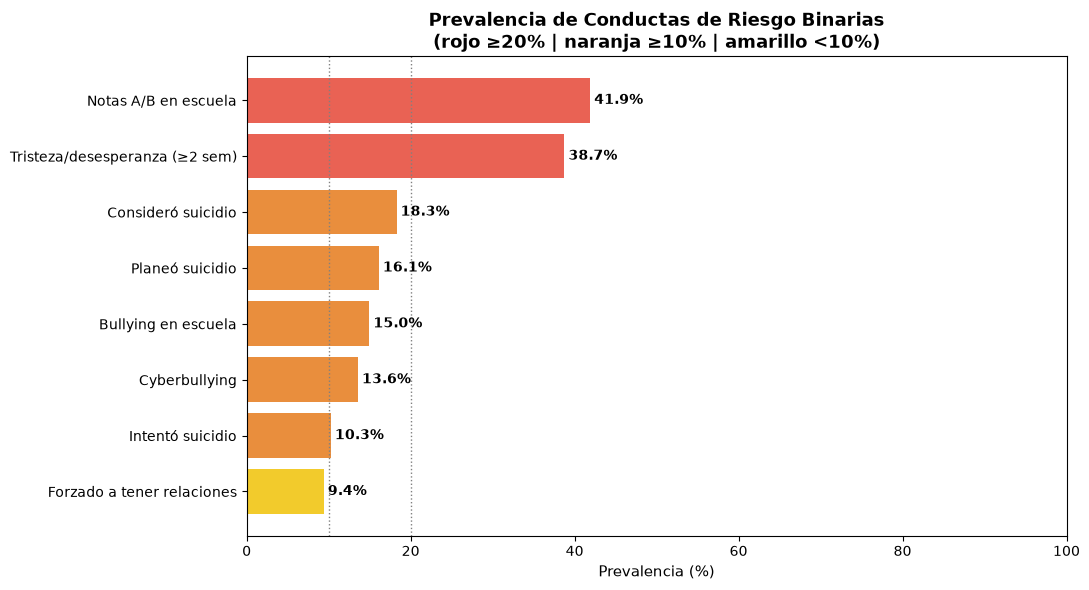

In [65]:
# PLOT 1 — VARIABLES BINARIAS: % EN RIESGO (barras horizontales)

binary_vars = {k: v for k, v in conductas.items()
               if v[1] == 'binary'}

risk_pct = {}
for col, info in binary_vars.items():
    s = df[col].dropna()
    risk_pct[info[0]] = (s == 1).mean() * 100

risk_series = pd.Series(risk_pct).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e74c3c' if v >= 20 else '#e67e22' if v >= 10
          else '#f1c40f' for v in risk_series.values]
bars = ax.barh(risk_series.index, risk_series.values, color=colors, alpha=0.88)

ax.set_xlabel("Prevalencia (%)", fontsize=11)
ax.set_title("Prevalencia de Conductas de Riesgo Binarias\n"
             "(rojo ≥20% | naranja ≥10% | amarillo <10%)",
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
ax.axvline(10, color='gray', linestyle=':', linewidth=1)
ax.axvline(20, color='gray', linestyle=':', linewidth=1)

for bar, val in zip(bars, risk_series.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

hallazgos relevantes:

- Tristeza/desesperanza: 38.7% — casi 4 de cada 10 estudiantes, alarmante. -> Buen predictor
- Consideró suicidio: 18.3% y Planeó suicidio: 16.1%; cifras muy altas que sugieren una crisis de salud mental importante en la muestra.
- Bullying: 15% y Cyberbullying: 13.6% 
- Notas A/B: 41.9%; es un factor protector, no de riesgo, hay que interpretarlo al revés.

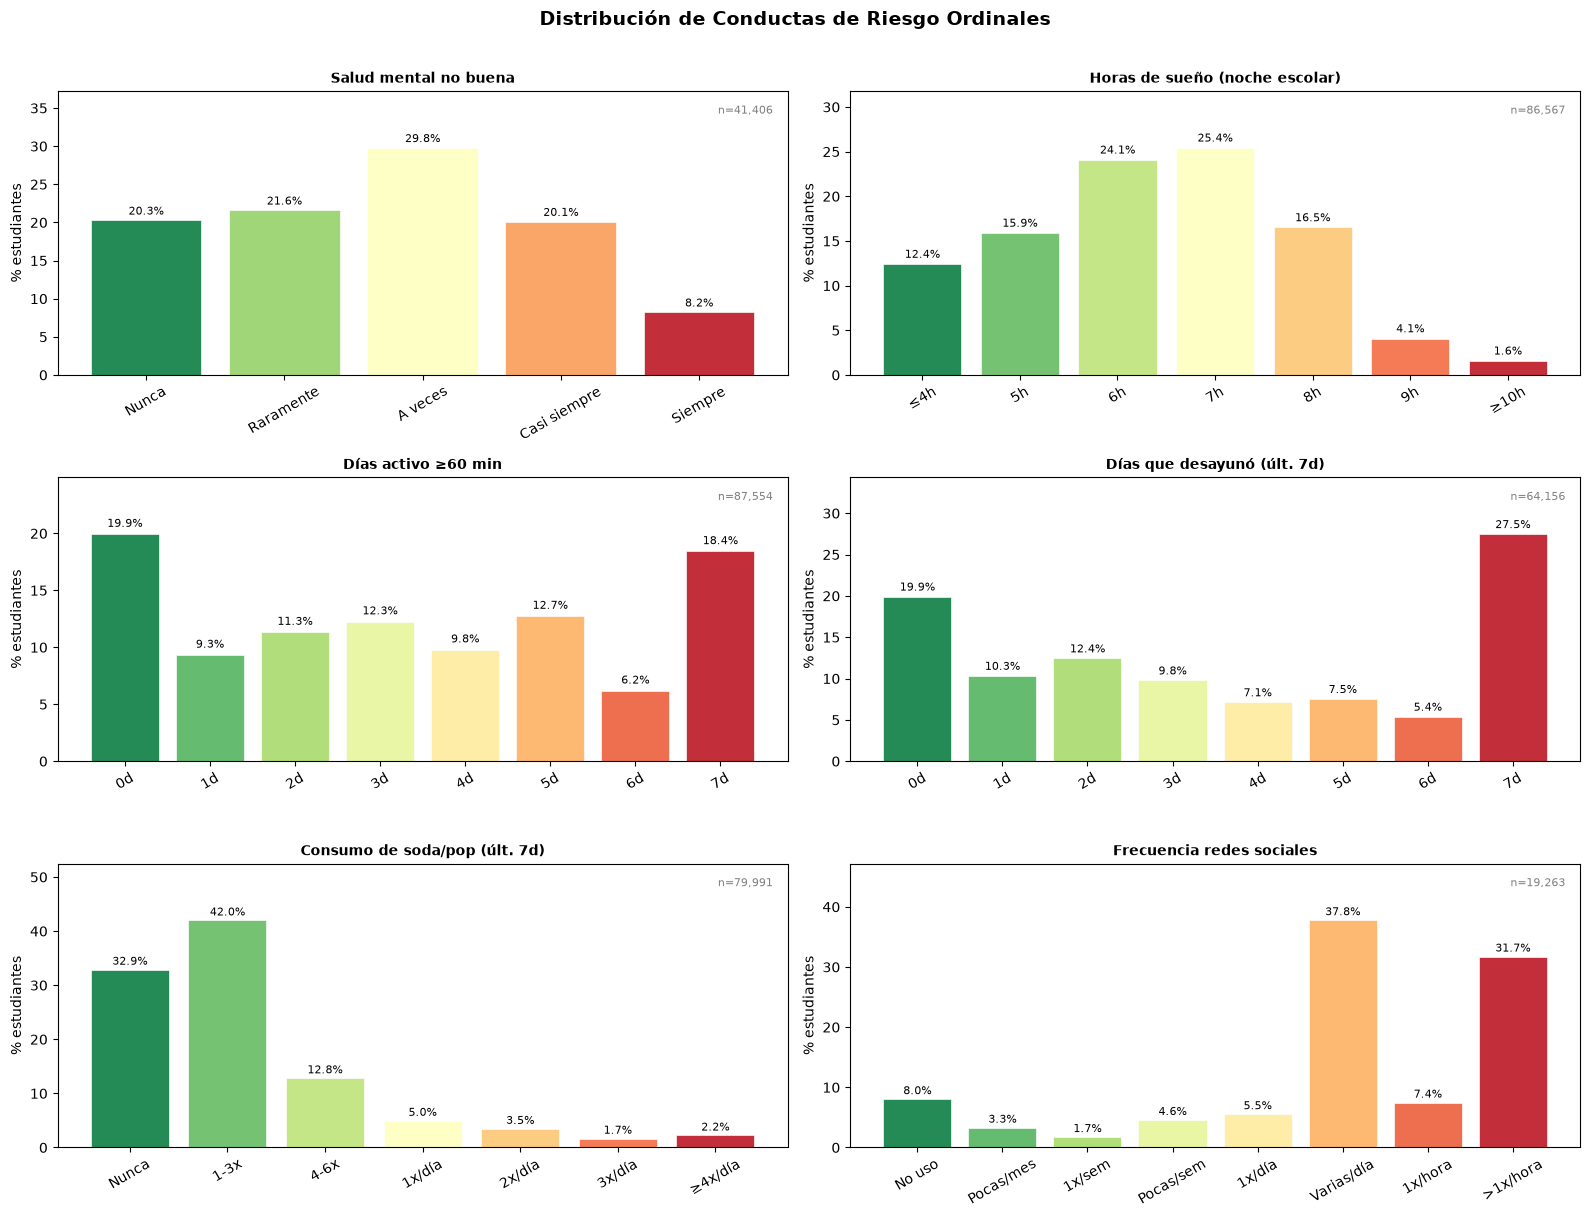

In [49]:
# PLOT 2 — VARIABLES ORDINALES: distribución completa

ordinal_vars = {k: v for k, v in conductas.items()
                if v[1] == 'ordinal'}

n = len(ordinal_vars)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for ax, (col, info) in zip(axes, ordinal_vars.items()):
    title   = info[0]
    mapping = info[2]
    pct     = get_prevalence(df, col, 'ordinal', mapping)

    n_cats  = len(pct)
    colors  = plt.cm.RdYlGn_r(np.linspace(0.05, 0.95, n_cats))

    bars = ax.bar(pct['categoria'].astype(str), pct['pct'],
                  color=colors, alpha=0.9, edgecolor='white', linewidth=0.5)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel("% estudiantes")
    ax.set_ylim(0, pct['pct'].max() * 1.25)
    ax.tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, pct['pct']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

    # N válidos
    n_valid = df[col].notna().sum()
    ax.text(0.98, 0.95, f'n={n_valid:,}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='gray')

# Ocultar subplots vacíos
for j in range(len(ordinal_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Conductas de Riesgo Ordinales",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Salud mental**:

- Solo el 20.3% reporta nunca tener mala salud mental.
- El 28.3% combinado entre "casi siempre" y "siempre" representa una carga muy significativa de malestar psicológico crónico.
- La distribución es relativamente plana con un peak en "a veces" (29.8%), lo que indica que el malestar mental es generalizado en la muestra.

**Sueño**:

- Solo el 16.5% duerme las 8 horas recomendadas y apenas 5.7% duerme 9h o más.
- La mayoría se concentra en 6–7 horas (24.1% y 25.4%), que está por debajo de las 8–10 horas recomendadas para adolescentes.
- El 12.4% duerme 4 horas o menos, lo cual es un factor de riesgo severo para salud mental.

**Actividad física**:

- Distribución en U: el 19.9% no hace actividad física ningún día, pero el 18.4% es activo los 7 días.
- La mayoría cae en rangos medios, con poca actividad consistente.
- Esto sugiere una polarización: estudiantes muy activos vs. completamente sedentarios.

**Desayuno**:

- Distribución bimodal clara: el 19.9% nunca desayuna vs. el 27.5% desayuna todos los días.
- Casi 1 de cada 5 estudiantes no desayuna nunca, lo que se asocia con peor rendimiento académico y salud mental.

**Soda/pop**:

- El 32.9% no consume y el 42% consume entre 1–3 veces a la semana, lo cual es relativamente moderado.
- Solo el 7.4% combina 3x/día o más.

**Redes sociales**:

- El n=19.263 es muy bajo comparado con las otras variables, lo que indica que esta pregunta solo estaba disponible en años recientes del dataset.
- El hallazgo más importante: 37.8% usa redes sociales varias veces al día y 31.7% más de una vez por hora. Combinados, casi el 70% tiene uso intensivo, lo que se asocia con peores outcomes de salud mental en adolescentes.

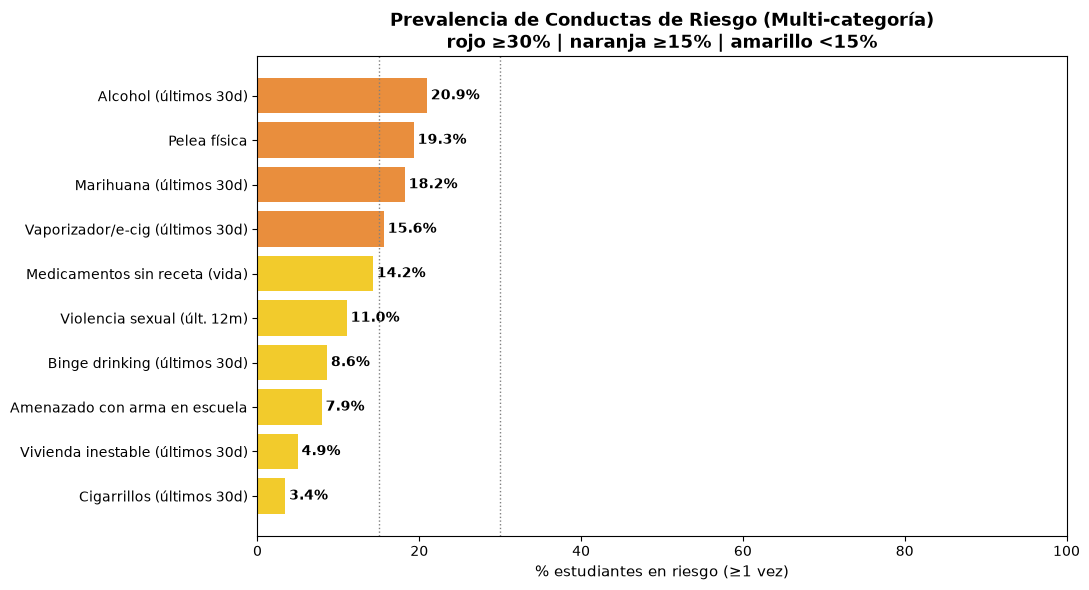

In [50]:
# PLOT 3 — VARIABLES MULTI-CATEGORÍA: % "en riesgo"
#           (cualquier categoría distinta de la primera)


multi_vars = {k: v for k, v in conductas.items()
              if v[1] == 'binary_first'}

risk_multi = {}
for col, info in multi_vars.items():
    s = df[col].dropna()
    # "En riesgo" = cualquier valor mayor a 1
    risk_multi[info[0]] = (s > 1).mean() * 100

risk_multi_series = pd.Series(risk_multi).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#e74c3c' if v >= 30 else '#e67e22' if v >= 15
          else '#f1c40f' for v in risk_multi_series.values]
bars = ax.barh(risk_multi_series.index, risk_multi_series.values,
               color=colors, alpha=0.88)

ax.set_xlabel("% estudiantes en riesgo (≥1 vez)", fontsize=11)
ax.set_title("Prevalencia de Conductas de Riesgo (Multi-categoría)\n"
             "rojo ≥30% | naranja ≥15% | amarillo <15%",
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
ax.axvline(15, color='gray', linestyle=':', linewidth=1)
ax.axvline(30, color='gray', linestyle=':', linewidth=1)

for bar, val in zip(bars, risk_multi_series.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

- Alcohol (20.9%) y pelea física (19.3%) lideran como conductas de riesgo de prevalencia media.
- Marihuana (18.2%) y vaporizador (15.6%) muestran que el consumo de sustancias es relevante, aunque los cigarrillos tradicionales (3.4%) están en claro declive, reemplazados por vaporizadores.
- Violencia sexual (11%) es una cifra alta considerando la gravedad de este evento.
- Vivienda inestable (4.9%) aunque parece baja, representa miles de estudiantes en situación vulnerable.
- Binge drinking (8.6%) es menor de lo esperado, pero probablemente sea una variable subestimada por auto-reporte.

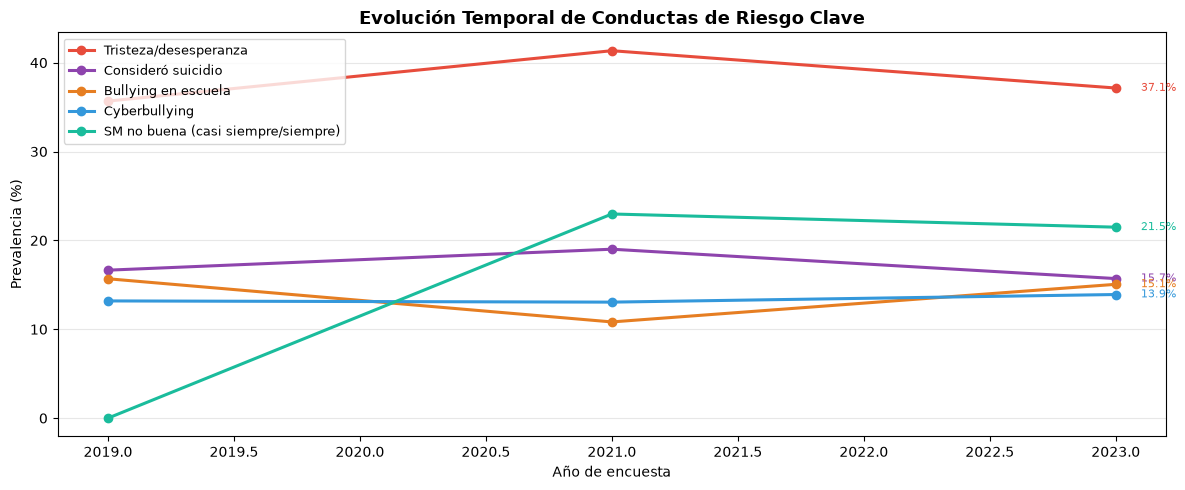

In [51]:
# PLOT 4 — EVOLUCIÓN TEMPORAL de conductas clave

temporal_vars = {
    'q26': 'Tristeza/desesperanza',
    'q27': 'Consideró suicidio',
    'q24': 'Bullying en escuela',
    'q25': 'Cyberbullying',
    'q84': 'SM no buena (casi siempre/siempre)',
}

fig, ax = plt.subplots(figsize=(12, 5))
colors_t = ['#e74c3c', '#8e44ad', '#e67e22', '#3498db', '#1abc9c']

for (col, label), color in zip(temporal_vars.items(), colors_t):
    if col == 'q84':
        # Solo categorías 4 y 5
        yearly = (df.groupby('year')
                    .apply(lambda x: (x[col].isin([4, 5])).mean() * 100)
                    .reset_index(name='pct'))
    else:
        yearly = (df.groupby('year')
                    .apply(lambda x: (x[col] == 1).mean() * 100)
                    .reset_index(name='pct'))

    ax.plot(yearly['year'], yearly['pct'],
            marker='o', linewidth=2.2, color=color, label=label)
    # Etiqueta al final de la línea
    ax.text(yearly['year'].iloc[-1] + 0.1,
            yearly['pct'].iloc[-1],
            f"{yearly['pct'].iloc[-1]:.1f}%",
            color=color, fontsize=8, va='center')

ax.set_xlabel("Año de encuesta")
ax.set_ylabel("Prevalencia (%)")
ax.set_title("Evolución Temporal de Conductas de Riesgo Clave",
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

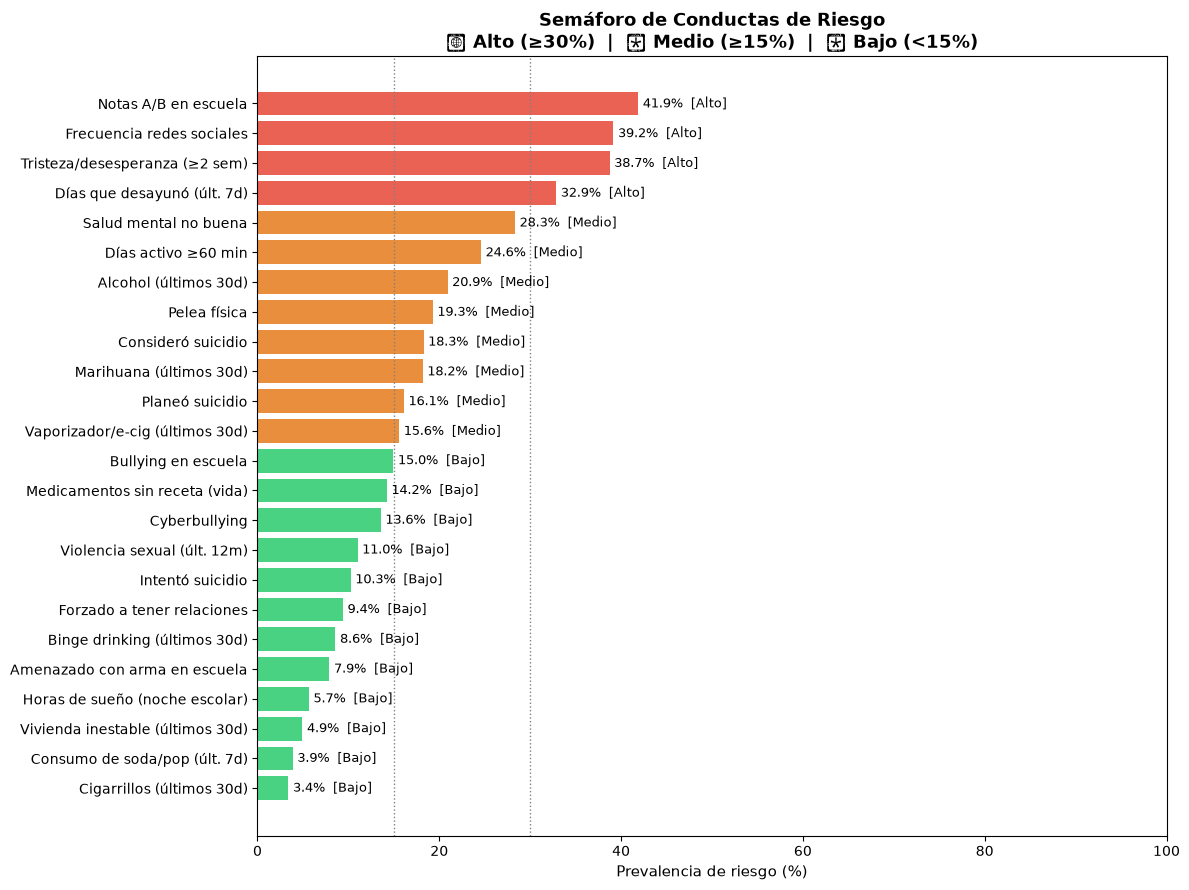

In [66]:
# PLOT 5 — RESUMEN EJECUTIVO: SEMÁFORO DE RIESGO

# Unificar todas las prevalencias de riesgo
all_risk = {}

for col, info in conductas.items():
    label    = info[0]
    var_type = info[1]
    s = df[col].dropna()

    if var_type == 'binary':
        pct = (s == 1).mean() * 100
    elif var_type == 'binary_first':
        pct = (s > 1).mean() * 100
    elif var_type == 'ordinal':
        # Últimas 2 categorías = mayor riesgo
        mapping = info[2]
        high_risk_vals = list(mapping.keys())[-2:]
        pct = s.isin(high_risk_vals).mean() * 100

    all_risk[label] = pct

risk_all_series = pd.Series(all_risk).sort_values(ascending=False)

# Semáforo
def semaforo(v):
    if v >= 30:   return '#e74c3c', 'Alto'
    elif v >= 15: return '#e67e22', 'Medio'
    else:         return '#2ecc71', 'Bajo'

colors_s = [semaforo(v)[0] for v in risk_all_series.values]
labels_s = [semaforo(v)[1] for v in risk_all_series.values]

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(risk_all_series.index[::-1],
               risk_all_series.values[::-1],
               color=colors_s[::-1], alpha=0.88)

ax.set_xlabel("Prevalencia de riesgo (%)", fontsize=11)
ax.set_title("Semáforo de Conductas de Riesgo\n"
             "🔴 Alto (≥30%)  |  🟠 Medio (≥15%)  |  🟢 Bajo (<15%)",
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 100)
ax.axvline(15, color='gray', linestyle=':', linewidth=1)
ax.axvline(30, color='gray', linestyle=':', linewidth=1)

for bar, val, lbl in zip(bars, risk_all_series.values[::-1], labels_s[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%  [{lbl}]',
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Riesgo Alto (≥30%)**:

- La tristeza/desesperanza (38.7%) y la salud mental deficiente son los problemas más prevalentes.
- El uso intensivo de redes sociales (39.2%) aparece como factor de riesgo estructural.
- Que el 32.9% no desayune nunca refleja vulnerabilidad socioeconómica.

**Riesgo Medio (15–30%)**:

- El cluster de conductas suicidas (consideró 18.3%, planeó 16.1%) junto con alcohol (20.9%) y marihuana (18.2%) sugiere que estas conductas están co-ocurriendo en los mismos estudiantes, lo que será relevante en el análisis de segmentación.

**Riesgo Bajo (<15%)**:

Aunque etiquetadas como "bajo", conductas como violencia sexual (11%) y forzado a tener relaciones (9.4%) son graves aunque poco frecuentes, y deben tratarse con cuidado en los modelos por el desbalance de clases.

### Correlaciones entre variables de salud mental

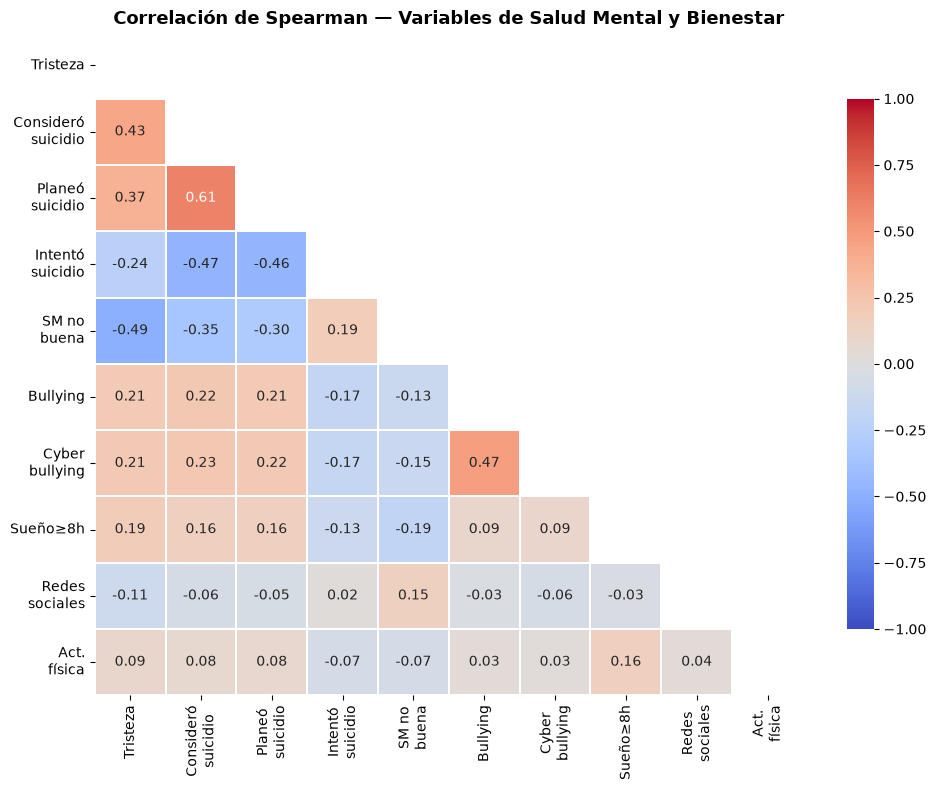

In [72]:
mental_health_vars = ['q26', 'q27', 'q28', 'q29_bin', 'q84',
                      'q24', 'q25', 'q85', 'q80', 'q76']
labels_mh = ['Tristeza', 'Consideró\nsuicidio', 'Planeó\nsuicidio', 'Intentó\nsuicidio',
             'SM no\nbuena', 'Bullying', 'Cyber\nbullying', 'Sueño≥8h',
             'Redes\nsociales', 'Act.\nfísica']

corr_spearman = df[mental_health_vars].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

sns.heatmap(
    corr_spearman,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    xticklabels=labels_mh,
    yticklabels=labels_mh,
    linewidths=0.3,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.8}
)

ax.set_title("Correlación de Spearman — Variables de Salud Mental y Bienestar",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlaciones positivas fuertes**:
- Consideró suicidio ↔ Planeó suicidio: 0.61; la más alta de la matriz. Tiene total sentido: quien planea un suicidio casi siempre lo consideró primero. Estas dos variables forman un cluster de ideación suicida que probablemente debería tratarse como una sola dimensión en el modelo.

- Bullying ↔ Cyberbullying: 0.47; los estudiantes que sufren acoso presencial también tienden a sufrirlo en línea. Sugiere que el acoso es un fenómeno transversal al medio, no específico de uno u otro canal.

- Tristeza ↔ Consideró suicidio: 0.43 y Tristeza ↔ Planeó suicidio: 0.37; confirman que q26 es una buena variable objetivo: está moderadamente correlacionada con las conductas suicidas pero no tan alta como para ser redundante.


**Correlaciones negativas relevantes**:
- SM no buena ↔ Tristeza: -0.49;  esta es la correlación más fuerte de toda la matriz en valor absoluto. Parece contraintuitivo que sea negativa, pero se explica por la codificación: en q84 los valores altos significan "siempre mala salud mental", mientras que en q26 el valor 1 significa "sí tristeza" y 2 "no tristeza". Es decir, la correlación negativa refleja una asociación positiva real entre ambos constructos, pero invertida por la escala. Esto es una señal de que antes del modelado hay que re-codificar las variables para que todas apunten en la misma dirección.

- SM no buena ↔ Consideró suicidio: -0.35 y SM no buena ↔ Planeó suicidio: -0.30; mismo fenómeno de codificación invertida.

- Intentó suicidio ↔ Consideró suicidio: -0.48 y Intentó suicidio ↔ Planeó suicidio: -0.47; aquí el signo negativo es sospechoso y probablemente refleja que q29 tiene codificación inversa respecto a q27 y q28 (recordemos que 1=no intentó, >1=sí intentó).

### Diferenciar por sexo en variables clave

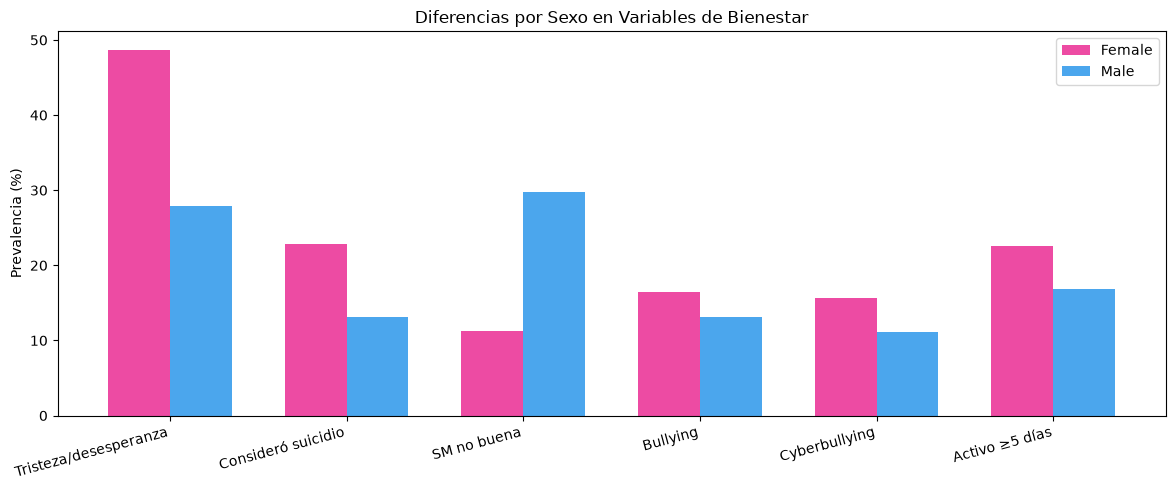

In [36]:
risk_vars = {
    'q26': 'Tristeza/desesperanza',
    'q27': 'Consideró suicidio',
    'q84': 'SM no buena',
    'q24': 'Bullying',
    'q25': 'Cyberbullying',
    'q76': 'Activo ≥5 días',
}

sex_prev = []
for var, label in risk_vars.items():
    for sex_code, sex_name in [(1, 'Female'), (2, 'Male')]:
        subset = df[df['sex'] == sex_code][var].dropna()
        pct = (subset == 1).mean() * 100
        sex_prev.append({'Variable': label, 'Sexo': sex_name, 'Prevalencia': pct})

sex_prev_df = pd.DataFrame(sex_prev)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(risk_vars))
width = 0.35
female = sex_prev_df[sex_prev_df['Sexo']=='Female']['Prevalencia'].values
male   = sex_prev_df[sex_prev_df['Sexo']=='Male']['Prevalencia'].values

bars1 = ax.bar(x - width/2, female, width, label='Female', color='#e91e8c', alpha=0.8)
bars2 = ax.bar(x + width/2, male,   width, label='Male',   color='#1e90e9', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(risk_vars.values()), rotation=15, ha='right')
ax.set_ylabel("Prevalencia (%)")
ax.set_title("Diferencias por Sexo en Variables de Bienestar")
ax.legend()
plt.tight_layout()
plt.show()

**Las mujeres reportan más malestar emocional**:

- Tristeza/desesperanza: 48.7% (F) vs 28.1% (M); la brecha más grande de la gráfica, casi 20 puntos porcentuales. Prácticamente 1 de cada 2 estudiantes mujeres reportó tristeza persistente, versus menos de 1 de cada 3 hombres. Este es uno de los hallazgos más robustos en la literatura de salud mental adolescente y se replica aquí con claridad. -> El género es un buen predictor. 

- Consideró suicidio: 23.1% (F) vs 13.2% (M); las mujeres casi duplican la prevalencia de ideación suicida. Consistente con la tristeza más alta.
Bullying: 16.4% (F) vs 13.2% (M) y Cyberbullying: 15.4% (F) vs 11.1% (M), las mujeres también sufren más acoso, especialmente digital, lo que puede estar relacionado con la mayor exposición a redes sociales.

**Los hombres reportan más conductas externalizantes**
- SM no buena: 11.3% (F) vs 30.1% (M); este resultado parece contraintuitivo dado que las mujeres tienen más tristeza. Sin embargo, recordando que q84 tiene codificación invertida: valores altos = peor salud mental. Lo que el gráfico probablemente está mostrando es el % en las categorías "casi siempre/siempre", y la diferencia inversa podría reflejar que los hombres tienden a reportar más frecuentemente estados extremos en esta escala particular, o un artefacto de codificación. Hay que revisarlo antes de incluirlo en el informe.

### Analisis Bivariado entre variable a predecir q26

In [37]:
# Preparación: etiqueta legible para q26
df['q26_label'] = df['q26'].map({1: 'Triste/Desesperanzado', 2: 'Sin tristeza'})

# Paleta consistente
palette = {1: '#e74c3c', 2: '#2ecc71'}
palette_label = {'Triste/Desesperanzado': '#e74c3c', 'Sin tristeza': '#2ecc71'}

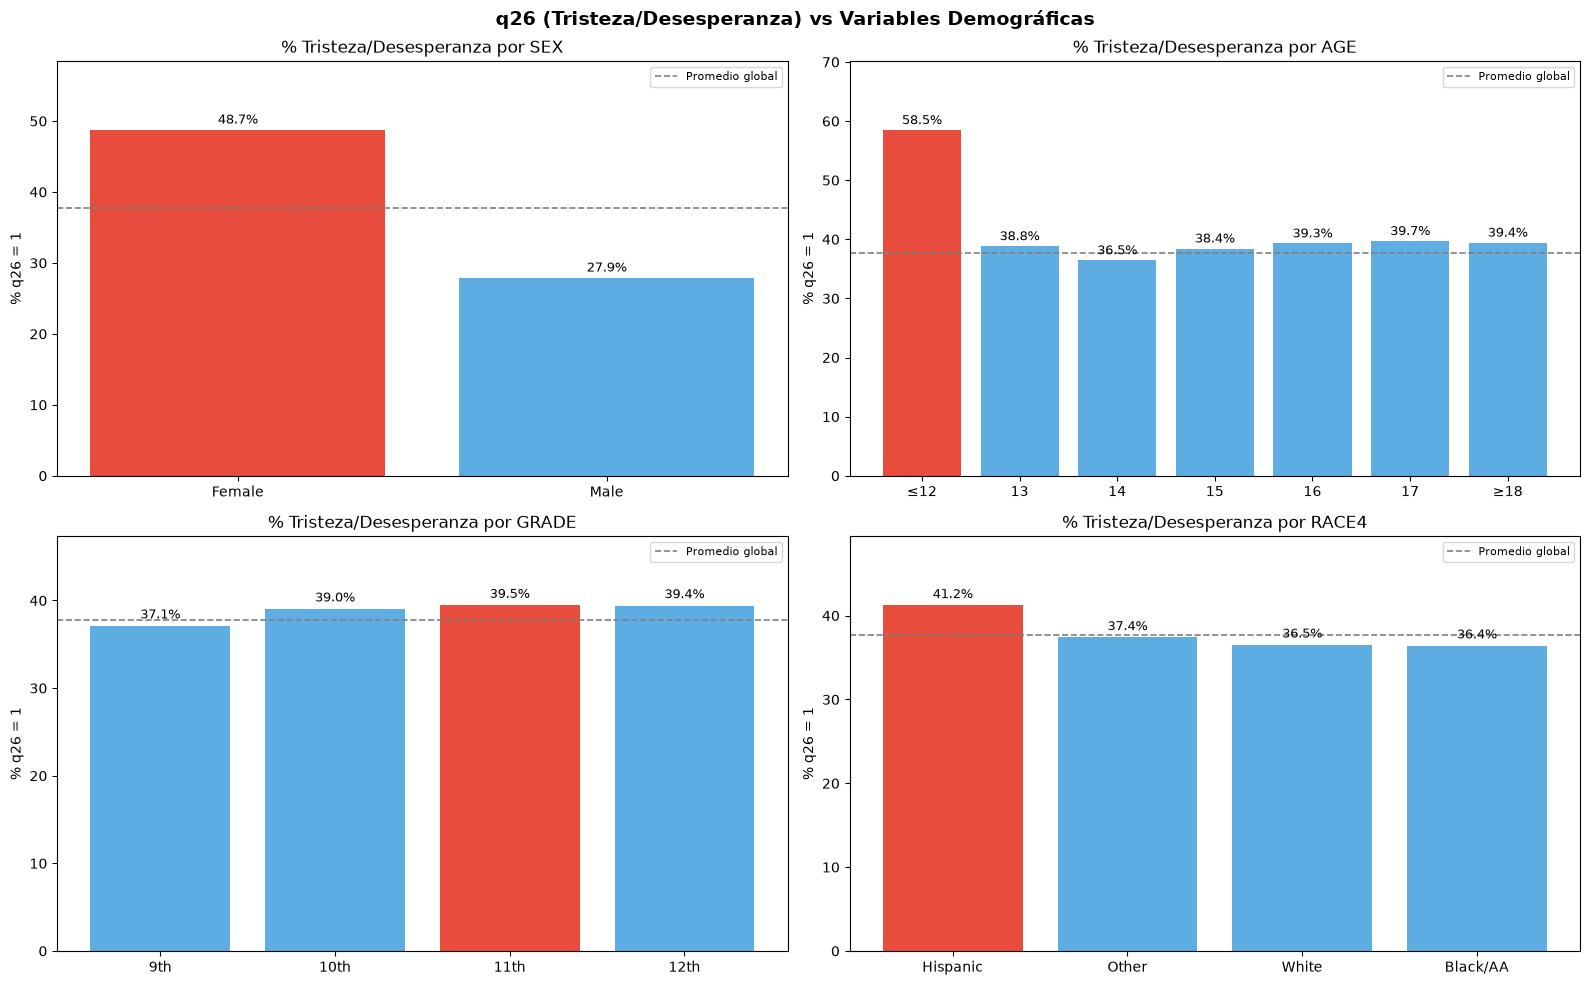

In [38]:
# q26 vs DEMOGRÁFICAS (age, sex, grade, race4)

demo_map = {
    'sex':   {1: 'Female', 2: 'Male'},
    'age':   {1:'≤12', 2:'13', 3:'14', 4:'15', 5:'16', 6:'17', 7:'≥18'},
    'grade': {1:'9th', 2:'10th', 3:'11th', 4:'12th', 5:'Other'},
    'race4': {1:'White', 2:'Black/AA', 3:'Hispanic', 4:'Other'},
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, mapping) in zip(axes, demo_map.items()):
    temp = df[['q26', col]].dropna().copy()
    temp[col] = temp[col].map(mapping)

    # % de q26=1 por categoría
    prev = (temp.groupby(col)['q26']
                .apply(lambda x: (x == 1).mean() * 100)
                .reset_index()
                .rename(columns={'q26': 'pct_triste'}))

    # Ordenar
    if col == 'age':
        order = list(mapping.values())
    elif col == 'grade':
        order = ['9th', '10th', '11th', '12th', 'Other']
    else:
        order = prev.sort_values('pct_triste', ascending=False)[col].tolist()

    prev[col] = pd.Categorical(prev[col], categories=order, ordered=True)
    prev = prev.sort_values(col)

    bars = ax.bar(prev[col], prev['pct_triste'],
                  color=['#e74c3c' if v == prev['pct_triste'].max()
                         else '#5dade2' for v in prev['pct_triste']])
    ax.set_title(f"% Tristeza/Desesperanza por {col.upper()}", fontsize=12)
    ax.set_ylabel("% q26 = 1")
    ax.set_ylim(0, prev['pct_triste'].max() * 1.2)
    ax.axhline(df['q26'].eq(1).mean() * 100, color='gray',
               linestyle='--', linewidth=1.2, label='Promedio global')
    ax.legend(fontsize=8)

    for bar, val in zip(bars, prev['pct_triste']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle("q26 (Tristeza/Desesperanza) vs Variables Demográficas",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- Sexo: La diferencia es la más grande de todo el análisis demográfico. Las mujeres tienen una prevalencia del 48.7% vs. 27.9% en hombres. Una brecha de casi 21 puntos porcentuales. Esto convierte al sexo en la variable demográfica más potente para el modelo, y refuerza que la segmentación por sexo va a producir submodelos con dinámicas muy distintas.

- Edad: El patrón más llamativo es que los estudiantes de ≤12 años tienen una prevalencia notablemente mayor (58.5%) que todos los demás grupos, que se concentran entre 36.5–39.7%. Esto puede deberse a sesgo de selección (estudiantes muy jóvenes en secundaria son una minoría con características particulares) más que a un efecto causal real de la edad. Para preprocesamiento, vale la pena evaluar si ese grupo tiene suficientes observaciones o si conviene agrupar con la categoría de 13 años.

- Grado: La variación es mínima (37.1%–39.5%). El grado no aporta poder discriminativo relevante para el modelo, y además está altamente correlacionado con la edad. Probable candidato a excluir o usar solo como variable de control demográfico.

- Raza: Los estudiantes hispanos tienen la mayor prevalencia (41.2%), seguidos de "Other" (37.4%), White (36.5%) y Black/AA (36.4%). Las diferencias son pequeñas, lo que sugiere que la raza por sí sola tiene poco poder predictivo, aunque puede ser relevante para la segmentación.

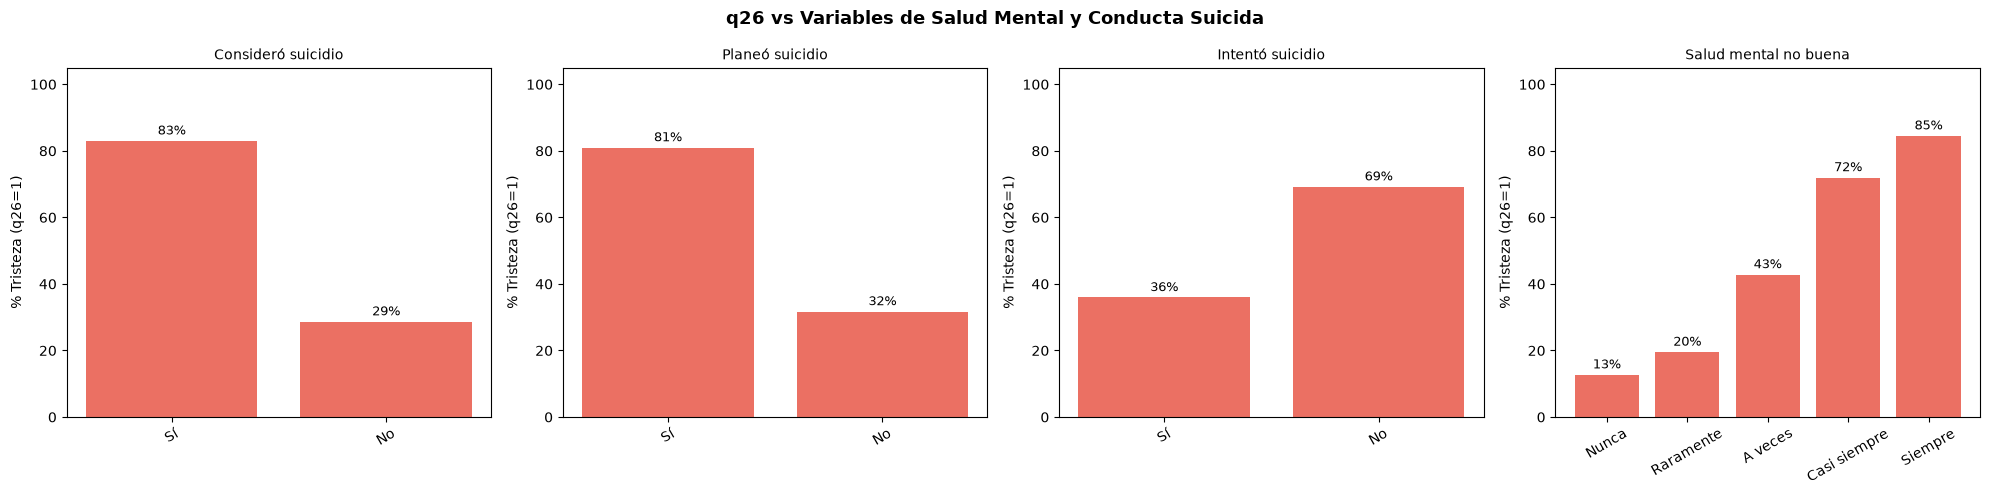

In [39]:
# q26 vs SALUD MENTAL Y SUICIDIO

mental_vars = {
    'q27': ('Consideró suicidio',    {1: 'Sí', 2: 'No'}),
    'q28': ('Planeó suicidio',       {1: 'Sí', 2: 'No'}),
    'q29': ('Intentó suicidio',      {1: 'Sí', 2: 'No'}),
    'q84': ('Salud mental no buena', {1:'Nunca', 2:'Raramente',
                                      3:'A veces', 4:'Casi siempre', 5:'Siempre'}),
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (col, (title, mapping)) in zip(axes, mental_vars.items()):
    temp = df[['q26', col]].dropna().copy()
    temp[col] = temp[col].map(mapping)

    prev = (temp.groupby(col)['q26']
                .apply(lambda x: (x == 1).mean() * 100)
                .reset_index()
                .rename(columns={'q26': 'pct'}))

    order = list(mapping.values())
    prev[col] = pd.Categorical(prev[col], categories=order, ordered=True)
    prev = prev.sort_values(col)

    bars = ax.bar(prev[col], prev['pct'], color='#e74c3c', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("% Tristeza (q26=1)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=30)

    for bar, val in zip(bars, prev['pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=9)

plt.suptitle("q26 vs Variables de Salud Mental y Conducta Suicida",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Este gráfico es el más importante conceptualmente porque muestra la estrecha relación entre q26 y otras variables del mismo bloque de salud mental.}

- El 83% de quienes consideraron suicidio reportó tristeza vs. solo 29% de quienes no lo consideraron. Similar para planeó suicidio (81% vs. 32%). Aquí aparece un problema importante para el modelado: q27, q28, q29, q30 son esencialmente co-síntomas o consecuencias del mismo estado mental que mide q26, no causas independientes. Si se incluyen como features, el modelo va a "hacer trampa", pues, prácticamente cualquier algoritmo va a aprender que "consideró suicidio → triste" y va a dar AUC altísimo sin aprender nada útil sobre intervención.

- El gráfico de salud mental no buena (q84) muestra un gradiente clarísimo: de 13% en quienes nunca reportan mala salud mental a 85% en quienes siempre la reportan. Esto es consistente con la correlación punto-biserial más alta que ya aparece en el gráfico 6 (q84 ≈ 0.49). Mismo problema de colinealidad conceptual: q84 mide casi lo mismo que q26, solo que con diferente formulación.

- Implicación para preprocesamiento: Definir dos grupos de features: (a) variables "proxies de la misma condición" (q27–q31, q84, q85) que deberían excluirse del modelo predictivo para evitar data leakage conceptual, y (b) variables de factores de riesgo reales (conductas, hábitos, violencia) que son las que generan valor para políticas públicas.

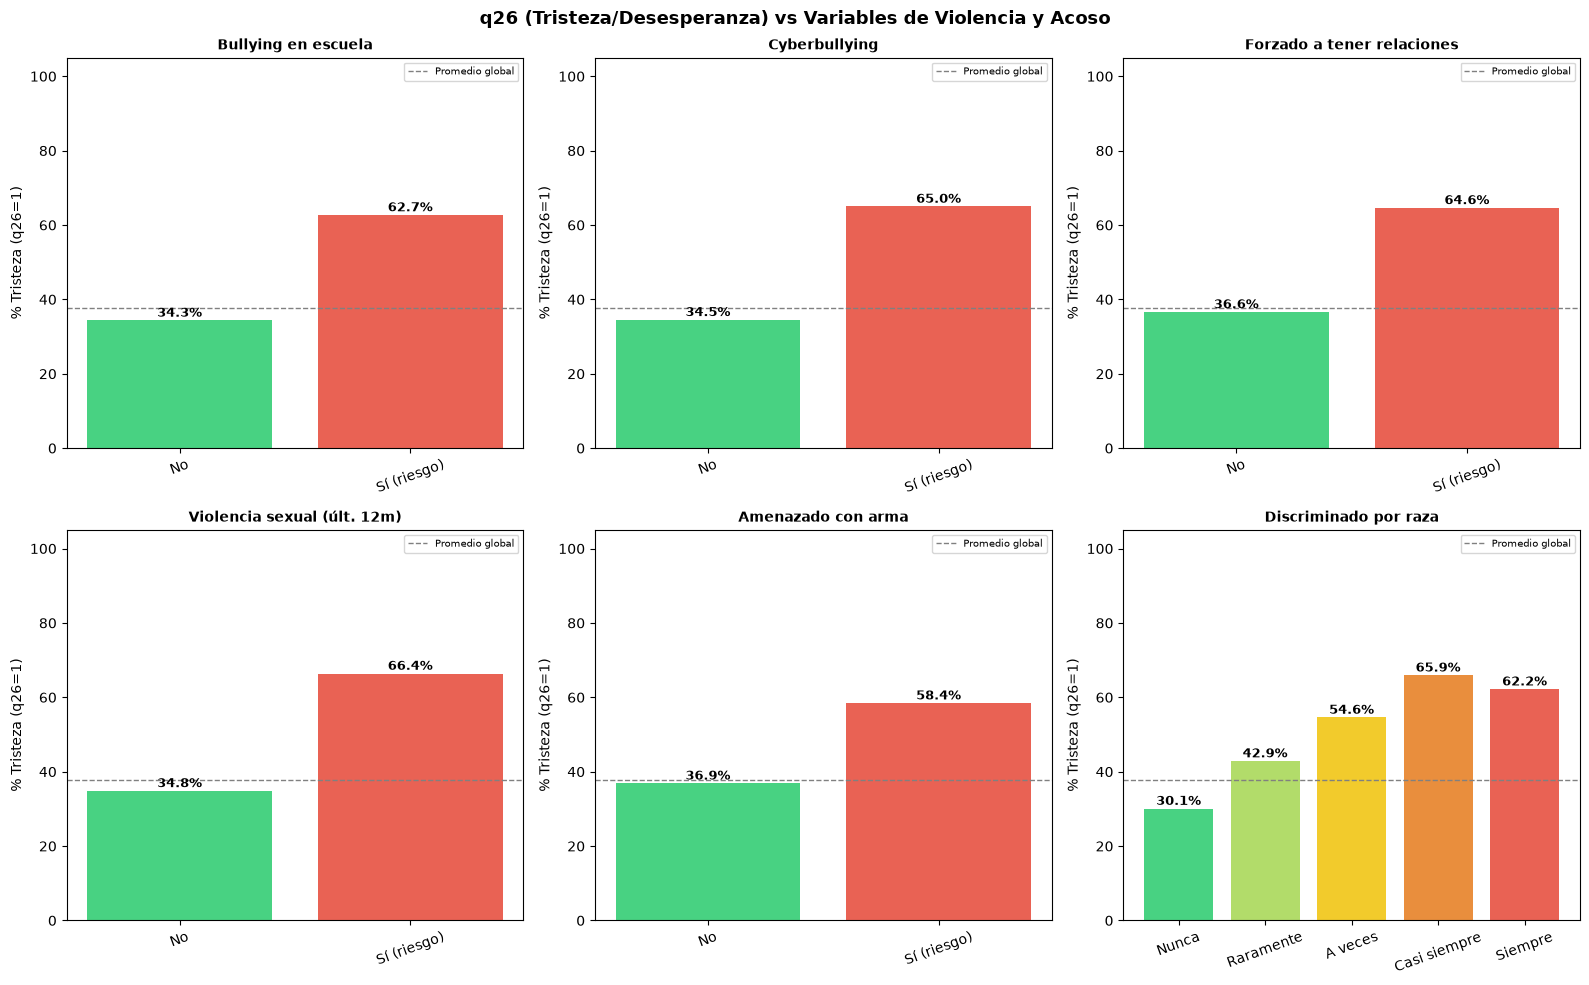

In [ ]:
# 3. q26 vs VIOLENCIA Y BULLYING


# q24 y q25: binarias (1=Sí, 2=No)
# q19:       binaria (1=Sí, 2=No)
# q20, q15:  múltiples categorías → binarizar (A=0 veces vs resto)
# q23:       múltiples categorías (Never/Rarely/Sometimes/Most/Always)

def binarize(series, zero_val):
    """Convierte a Sí/No: zero_val → 'No', resto → 'Sí (riesgo)'"""
    return series.map(lambda x: 'No' if x == zero_val else 'Sí (riesgo)')

violence_vars = {
    'q24': ('Bullying en escuela',         'binary_12'),
    'q25': ('Cyberbullying',               'binary_12'),
    'q19': ('Forzado a tener relaciones',  'binary_12'),
    'q20': ('Violencia sexual (últ. 12m)', 'binary_first'),  # 1=0 veces
    'q15': ('Amenazado con arma',          'binary_first'),  # 1=0 veces
    'q23': ('Discriminado por raza',       'ordinal'),
}

ordinal_map_q23 = {1:'Nunca', 2:'Raramente', 3:'A veces',
                   4:'Casi siempre', 5:'Siempre'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (col, (title, var_type)) in zip(axes, violence_vars.items()):
    temp = df[['q26', col]].dropna().copy()

    if var_type == 'binary_12':
        # 1=Sí (riesgo), 2=No
        temp['categoria'] = temp[col].map({1: 'Sí (riesgo)', 2: 'No'})
        order = ['No', 'Sí (riesgo)']
        color_map = {'Sí (riesgo)': '#e74c3c', 'No': '#2ecc71'}

    elif var_type == 'binary_first':
        # 1=sin riesgo (0 veces), resto=riesgo
        temp['categoria'] = temp[col].apply(
            lambda x: 'No' if x == 1 else 'Sí (riesgo)'
        )
        order = ['No', 'Sí (riesgo)']
        color_map = {'Sí (riesgo)': '#e74c3c', 'No': '#2ecc71'}

    elif var_type == 'ordinal':
        temp['categoria'] = temp[col].map(ordinal_map_q23)
        order = list(ordinal_map_q23.values())
        # Degradado de verde a rojo
        n = len(order)
        hex_colors = [
            '#2ecc71', '#a8d855', '#f1c40f', '#e67e22', '#e74c3c'
        ]
        color_map = dict(zip(order, hex_colors))

    # Calcular prevalencia
    prev = (temp.groupby('categoria')['q26']
                .apply(lambda x: (x == 1).mean() * 100)
                .reset_index()
                .rename(columns={'q26': 'pct'}))

    # Respetar orden
    prev['categoria'] = pd.Categorical(prev['categoria'],
                                        categories=order, ordered=True)
    prev = prev.sort_values('categoria')

    colors = [color_map.get(v, '#95a5a6') for v in prev['categoria']]
    bars = ax.bar(prev['categoria'], prev['pct'], color=colors, alpha=0.88)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel("% Tristeza (q26=1)")
    ax.set_ylim(0, 105)
    ax.axhline(df['q26'].eq(1).mean() * 100, color='gray',
               linestyle='--', linewidth=1, label='Promedio global')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=20)

    for bar, val in zip(bars, prev['pct']):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle("q26 (Tristeza/Desesperanza) vs Variables de Violencia y Acoso",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Todos los indicadores de violencia muestran el mismo patrón: quienes reportan exposición tienen una prevalencia de tristeza ~28–30 puntos porcentuales por encima de quienes no la reportan. Los valores son consistentes:

- Bullying escolar: 34.3% (No) vs. 62.7% (Sí)
- Cyberbullying: 34.5% vs. 65%
- Forzado a tener relaciones: 36.6% vs. 64.6%
- Violencia sexual últimos 12 meses: 34.8% vs. 66.4%
- Amenazado con arma: 36.9% vs. 58.4%

La discriminación racial muestra un gradiente ordenado y limpio (30.1% a 65.9% de "Casi siempre"), lo que sugiere una relación dosis-respuesta, esto es útil para modelos que puedan capturar no-linealidades.

Estas variables son excelentes candidatas para el modelo porque representan factores accionables desde política pública (programas anti-bullying, educación en relaciones sanas, etc.) y tienen diferencias grandes y consistentes.

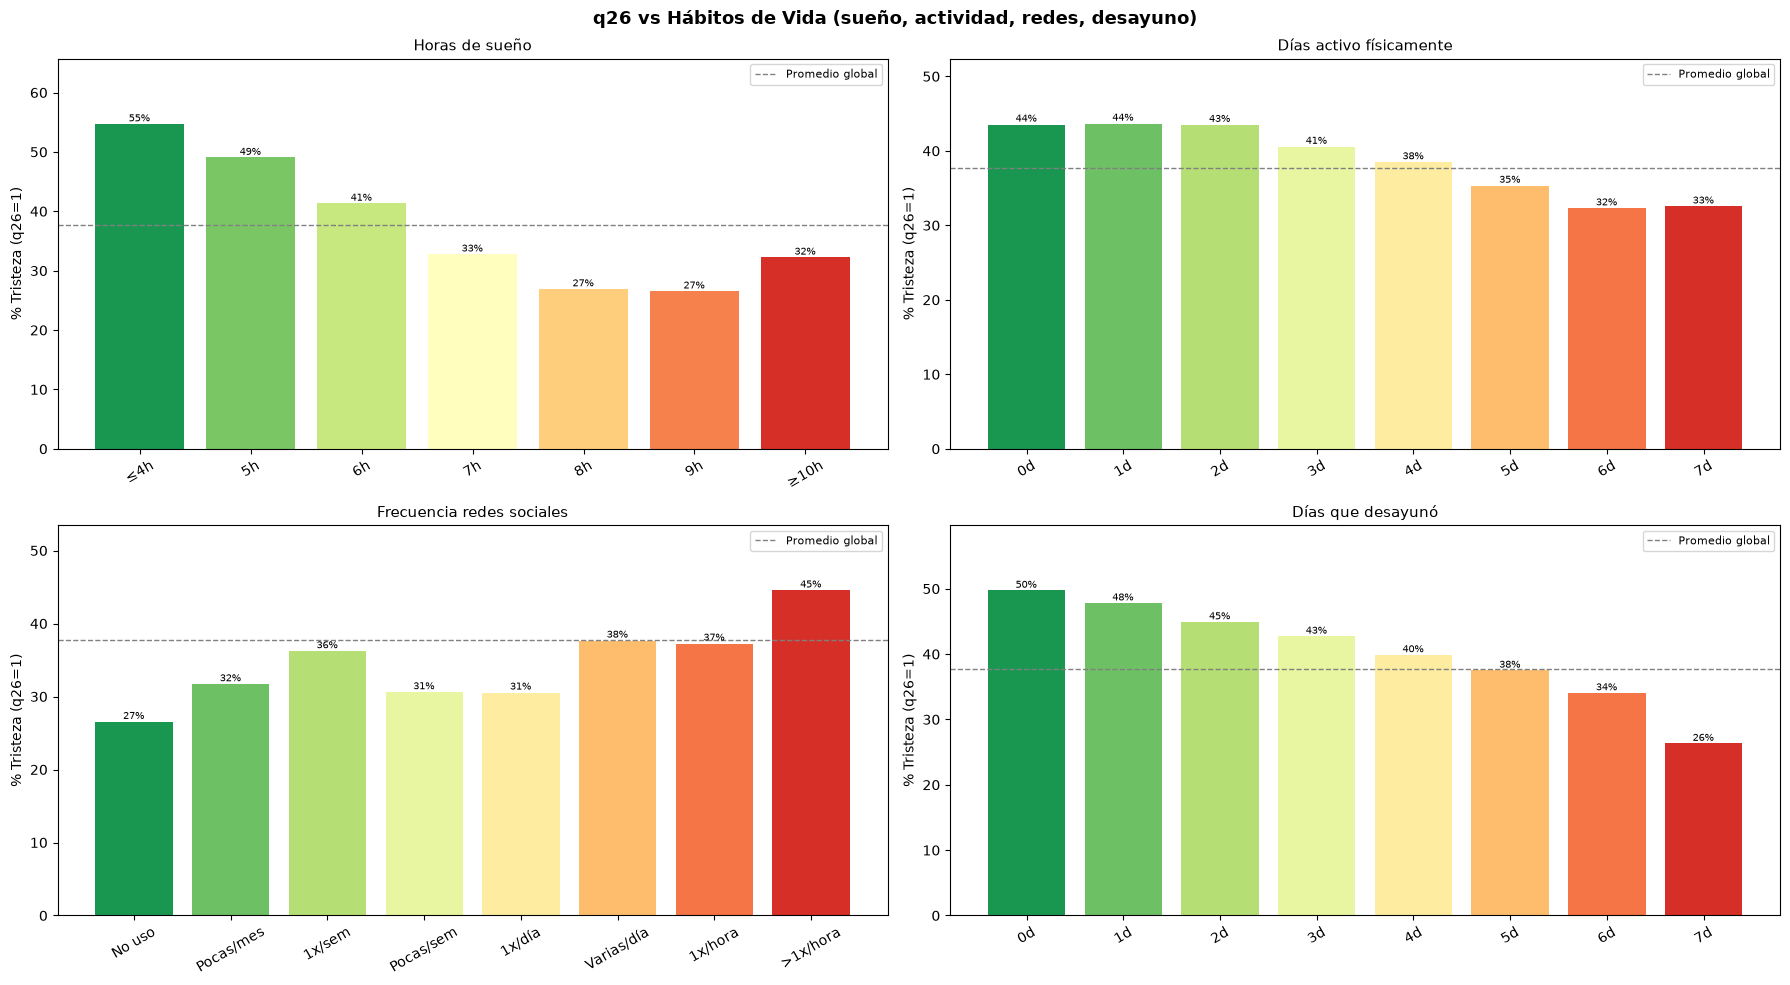

In [43]:
# 4. q26 vs HÁBITOS DE VIDA

lifestyle_vars = {
    'q85': ('Horas de sueño',
            {1:'≤4h', 2:'5h', 3:'6h', 4:'7h', 5:'8h', 6:'9h', 7:'≥10h'}),
    'q76': ('Días activo físicamente',
            {1:'0d', 2:'1d', 3:'2d', 4:'3d', 5:'4d', 6:'5d', 7:'6d', 8:'7d'}),
    'q80': ('Frecuencia redes sociales',
            {1:'No uso', 2:'Pocas/mes', 3:'1x/sem', 4:'Pocas/sem',
             5:'1x/día', 6:'Varias/día', 7:'1x/hora', 8:'>1x/hora'}),
    'q75': ('Días que desayunó',
            {1:'0d', 2:'1d', 3:'2d', 4:'3d', 5:'4d', 6:'5d', 7:'6d', 8:'7d'}),
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for ax, (col, (title, mapping)) in zip(axes, lifestyle_vars.items()):
    temp = df[['q26', col]].dropna().copy()
    temp[col] = temp[col].map(mapping)

    prev = (temp.groupby(col)['q26']
                .apply(lambda x: (x == 1).mean() * 100)
                .reset_index()
                .rename(columns={'q26': 'pct'}))

    order = list(mapping.values())
    prev[col] = pd.Categorical(prev[col], categories=order, ordered=True)
    prev = prev.sort_values(col)

    # Colormap degradado por nivel
    n = len(prev)
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, n))

    bars = ax.bar(prev[col], prev['pct'], color=colors)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("% Tristeza (q26=1)")
    ax.set_ylim(0, prev['pct'].max() * 1.2)
    ax.tick_params(axis='x', rotation=30)
    ax.axhline(df['q26'].eq(1).mean() * 100, color='gray',
               linestyle='--', linewidth=1, label='Promedio global')
    ax.legend(fontsize=8)

    for bar, val in zip(bars, prev['pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.0f}%', ha='center', fontsize=7)

plt.suptitle("q26 vs Hábitos de Vida (sueño, actividad, redes, desayuno)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

- Horas de sueño: El patrón más claro y limpio de todo el análisis. A menos horas de sueño, mayor tristeza: 55% con ≤4h, bajando monótonamente hasta 27% con 8–9h, con un leve repunte en ≥10h (probablemente hipersomnia asociada a depresión). Esta relación no-lineal (U invertida con punto de inflexión en 8h) es relevante para el modelado: conviene tratarla como ordinal o crear features que capturen la desviación del óptimo en ambas direcciones.

- Actividad física: Los que no hacen actividad (0d) tienen la mayor prevalencia (44%), y disminuye hasta 32–33% con actividad diaria. La relación es monotónica pero de magnitud moderada. Para preprocesamiento, vale la pena considerar si esta variable tiene muchos NaN o si hay sesgo de respuesta.

- Redes sociales: El efecto es solo relevante en el extremo superior: quienes usan redes más de 1 vez/hora tienen 45% de prevalencia, mientras el resto oscila entre 27–38% sin patrón muy claro. El umbral de uso muy intensivo (>1x/hora) podría justificar crear una variable binaria de "uso problemático".

- Desayuno: quienes nunca desayunan tienen 50% de prevalencia, vs. 26% quienes desayunan los 7 días. Puede ser proxy de condición socioeconómica o de desregulación de rutinas asociada al bienestar general.

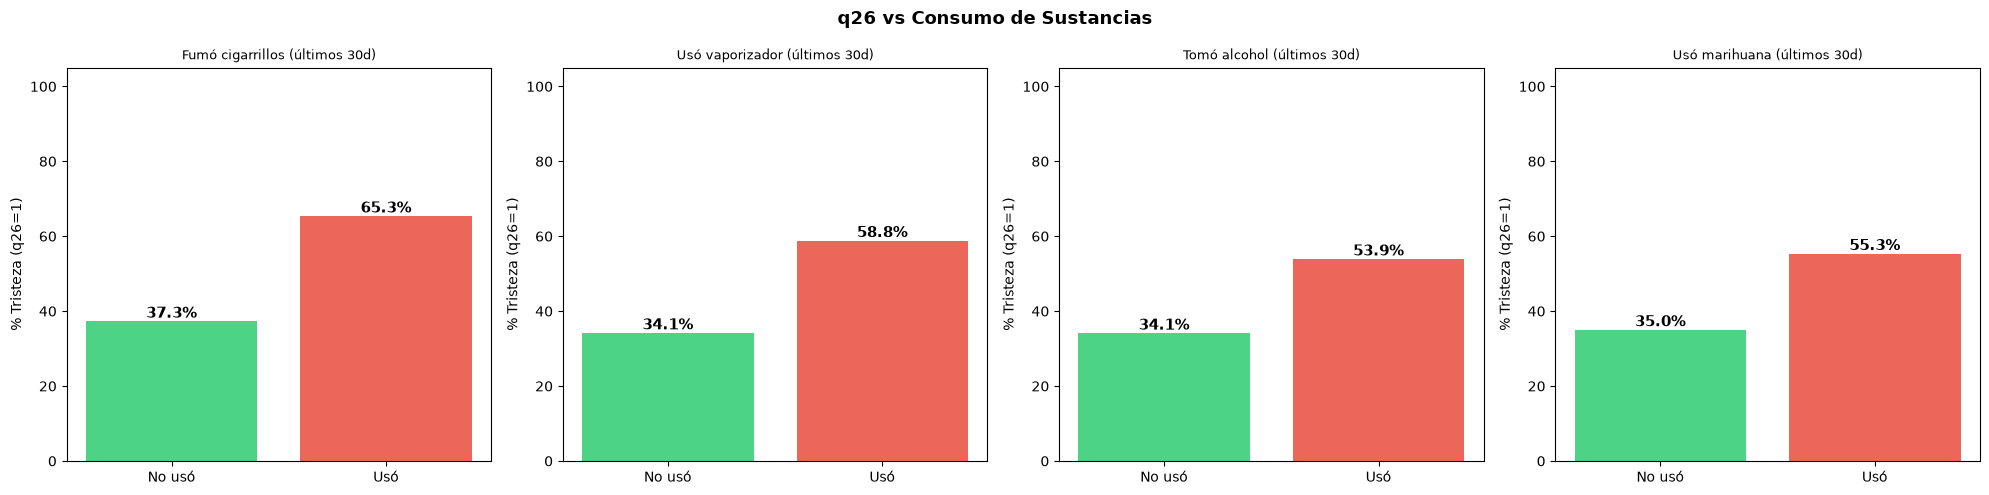

In [44]:
# 5. q26 vs SUSTANCIAS

sustancias_vars = {
    'q33': 'Fumó cigarrillos (últimos 30d)',
    'q36': 'Usó vaporizador (últimos 30d)',
    'q42': 'Tomó alcohol (últimos 30d)',
    'q48': 'Usó marihuana (últimos 30d)',
}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (col, title) in zip(axes, sustancias_vars.items()):
    temp = df[['q26', col]].dropna().copy()

    # Binarizar: 1="no usó" (código 1), >1="usó"
    temp['uso'] = temp[col].apply(lambda x: 'Usó' if x > 1 else 'No usó')

    prev = (temp.groupby('uso')['q26']
                .apply(lambda x: (x == 1).mean() * 100)
                .reset_index()
                .rename(columns={'q26': 'pct'}))

    colors = ['#e74c3c' if v == 'Usó' else '#2ecc71' for v in prev['uso']]
    bars = ax.bar(prev['uso'], prev['pct'], color=colors, alpha=0.85)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("% Tristeza (q26=1)")
    ax.set_ylim(0, 105)

    for bar, val in zip(bars, prev['pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.suptitle("q26 vs Consumo de Sustancias",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Todas las sustancias muestran un patrón consistente: quienes consumen tienen ~19–28 puntos más de prevalencia de tristeza. Los efectos son de magnitud similar entre tabaco (65.3%), vaporizador (58.8%), alcohol (53.9%) y marihuana (55.3%). La dirección de causalidad es ambigua (el consumo puede ser causa o consecuencia de la tristeza), pero todas son variables relevantes para el modelo -> Se pueden unificar en una sola variable.

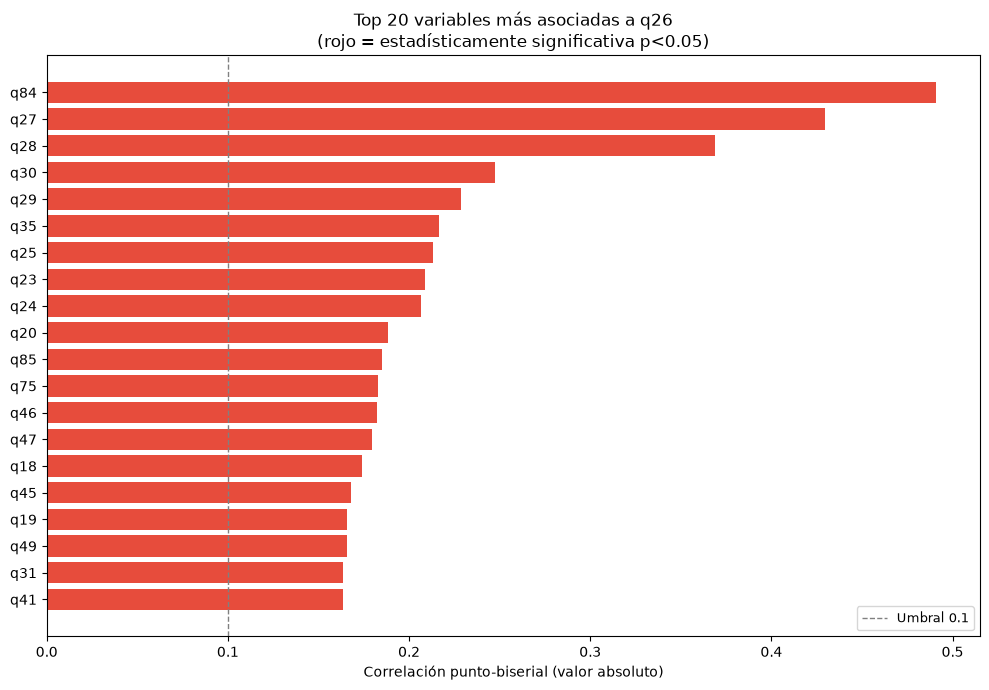


Top 10 variables más asociadas a q26:
variable     corr          pval
     q84 0.490620  0.000000e+00
     q27 0.429838  0.000000e+00
     q28 0.369071  0.000000e+00
     q30 0.247646  0.000000e+00
     q29 0.228907  0.000000e+00
     q35 0.216691  0.000000e+00
     q25 0.213251  0.000000e+00
     q23 0.208630 6.803261e-188
     q24 0.206381  0.000000e+00
     q20 0.188181  0.000000e+00


In [45]:
# 6. RESUMEN: RANKING DE VARIABLES POR ASOCIACIÓN

all_q_vars = [c for c in df.columns
              if c.startswith('q') and c != 'q26'
              and c not in ['q26_label', 'q63', 'q64', 'q65']]

associations = []
for col in all_q_vars:
    temp = df[['q26', col]].dropna()
    if len(temp) < 500 or temp[col].nunique() < 2:
        continue
    # Point-biserial: correlación entre q26 binaria y la variable
    from scipy.stats import pointbiserialr
    try:
        corr, pval = pointbiserialr((temp['q26'] == 1).astype(int), temp[col])
        associations.append({'variable': col, 'corr': abs(corr), 'pval': pval})
    except:
        pass

assoc_df = (pd.DataFrame(associations)
              .sort_values('corr', ascending=False)
              .head(20))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in assoc_df['pval']]
bars = ax.barh(assoc_df['variable'][::-1], assoc_df['corr'][::-1], color=colors[::-1])
ax.set_xlabel("Correlación punto-biserial (valor absoluto)")
ax.set_title("Top 20 variables más asociadas a q26\n(rojo = estadísticamente significativa p<0.05)",
             fontsize=12)
ax.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='Umbral 0.1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 variables más asociadas a q26:")
print(assoc_df[['variable', 'corr', 'pval']].head(10).to_string(index=False))

Esto confirma la estructura que se anticipó:

- q84 (salud mental no buena) y q27–q30 (conductas suicidas) encabezan con correlaciones 0.37–0.49: son esencialmente la misma dimensión latente que q26. Se deben excluir del set de features.

- q35 y q25 aparecen en posiciones intermedias (~0.22), estas sí son variables de riesgo legítimas.

- El bloque de variables con correlaciones 0.16–0.22 (q20, q85, q75, q46, q47, q18, q45, q19, q49, q31, q41) constituye el corazón del modelo predictivo real.



### Acciones a considerar en preprocesamiento en base a lo hayado en EDA:

1. **Selección y exclusión de variables**

- Variables a excluir completamente (no son features): Las variables de muestra (sitecode, sitename, sitetype, sitetypenum, year, survyear, weight, stratum, PSU, record) son identificadores y ponderadores del diseño muestral, no características del estudiante.

- Las variables co-síntoma (q27, q28, q29_bin, q30, q84, q85) encabezan el ranking de correlación con q26. Son medidas de la misma ideación/conducta suicida y mala salud mental, no factores de riesgo independientes. Incluirlas provocaría data leakage conceptual: el modelo aprendería "quien consideró suicidio está triste" y daría AUC inflado sin ningún valor para política pública.

- Las variables de identidad sexual (sexid, sexid2, sexpart, sexpart2, transg, sextrans) tienen hasta 71.2% de nulos porque no fueron incluidas en todos los años ni en todos los distritos (la documentación lo confirma). Con ese porcentaje de missings estructurales, cualquier imputación sería inválida, por lo que, excluirlas del modelo principal y reservarlas para análisis exploratorio complementario.

- Las variables BMI continuas (stheight, stweight, bmi, bmipct) tienen 13.9% de nulos y son redundantes con los indicadores dicotómicos qnobese y qnowt (12.7% y 13.9% de prevalencia respectivamente), que son más directos. Se puede optar por usar solo los indicadores dicotómicos y descartar las continuas, o incluir bmi como feature continua con imputación por mediana.

2. Tratamiento de valores nulos

Los nulos en este dataset son de dos tipos distintos y deben tratarse diferente:

- Nulos estructurales: Ocurren porque ciertos distritos/años no incluyeron ciertas preguntas en el cuestionario. Imputar estos nulos sería incorrecto, pues el valor no existe, no es una no-respuesta. Para variables con >50% de nulos en el set de cuestionario (q80, q78, y otras 17 identificadas), la estrategia más adecuada es excluirlas del modelo. 

- Nulos por no-respuesta o skip patterns: Para las variables predictoras principales con nulos moderados (<30%), se puede imputar. Las opciones son:

    - Moda para variables binarias y ordinales de pocos niveles (es la más defensible en encuestas de conducta donde el patrón de respuesta es asimétrico).
    - KNNImputer si se quiere capturar correlaciones entre variables al imputar, aunque es más costoso computacionalmente con 99,778 filas.

- La variable objetivo q26 tiene que resolverse primero: las filas con q26 nulo se eliminan (no se imputa la variable a predecir).



3. Recodificación de dirección (variables ordinales)

Este es quizás el punto más importante para la correcta interpretación de los modelos. Varias variables están codificadas de forma que "mayor valor = menos riesgo", lo que es contraintuitivo y puede confundir la interpretación de coeficientes y SHAP:

- q84 (salud mental): 1 = nunca mala → 5 = siempre mala. Dirección: valores altos = más riesgo. Está bien como está, pero hay que documentarlo.
- q85 (notas): 1 = mayormente A → 6 = mayormente F. Valores altos = peor rendimiento = más riesgo. Está bien como está. 
- q29 (intentó suicidio): ya fue corregido a q29_bin.
- Horas de sueño: El gráfico muestra relación U-shape — poco sueño (≤4h, 55%) y mucho sueño (≥10h, 32%) ambos asociados a mayor tristeza, con mínimo en 8–9h. Conviene crear una feature de "desviación del óptimo de sueño" en lugar de usar el valor ordinal directo.

Entonces, se debe revisar sistemáticamente todas las variables ordinales contra la documentación y verificar que mayor valor = mayor riesgo antes de entrenar cualquier modelo. Esto es especialmente crítico para regresión logística y árboles donde la dirección del efecto importa.


4. Encoding de variables categóricas
- race4 / race7: Son nominales sin orden natural. Requieren one-hot encoding (4 dummies para race4, descartando una categoría de referencia). Con árboles/XGBoost se puede usar label encoding sin problema, pero para regresión logística el one-hot es necesario.
- sex: Ya está codificada como binaria (1=Female, 2=Male). Es mejor recodificarla a 0/1 para consistencia.
- age: Ordinal (1=≤12 años ... 7=≥18). Se puede usar como ordinal numérica o crear dummies. 


5. Detección y tratamiento de outliers
BMI: La distribución mostró cola larga hacia valores altos (~80), correspondiente a obesidad severa. No son errores de medición, son valores reales pero extremos. Aunque, la variable continua podría simplemente excluirse.

Las variables de cuestionario (binarias y ordinales de escala fija) no tienen outliers por construcción, pues se asume que sus rangos están definidos por el cuestionario.

6. Feature engineering puntual
Dos features nuevas que en el EDA se justifican directamente:

- redes_intensivo: Binaria = 1 si uso de redes >1x/hora. El gráfico de hábitos mostró que el efecto es solo relevante en ese umbral extremo (45% de tristeza vs. 27–38% en todos los demás grupos).

- sleep_deviation: |horas_sueño_óptimas − horas_reportadas|, para capturar la relación U-shape.


7. Desbalance de clases
- q26 tiene prevalencia de 38.7%. No es un desbalance severo (70/30 aproximado).Se debe monitorear que el modelo no colapse al predecir siempre la clase mayoritaria. Se debe usar `class_weight='balanced'` en regresión logística y ajustar `scale_pos_weight` en XGBoost como medida preventiva.

# 2. Preprocesamiento

## imputación de nulos




## encoding de categóricas

## detección de outliers

## reducción de variables (PCA / selección)

# 3. Definición de métrica de bienestar

# 4. Modelos 




## train/test split

## tuning de hiperparámetros

## evaluación y comparación

# 5. Segmentación

## clustering por grupo demográfico/geográfico


## re-aplicar modelos por segmento

# 6. SHAP / interpretabilidad

# 7. Propuestas de política pública